In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import glob
import functools
from hyppo.ksample import Hotelling
import logging
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import quantities as pq
import scipy.stats as stats

import epych
from epych.statistics import alignment

[striatum:4058336] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/805371904/shared_mem_cuda_pool.striatum could be created.
[striatum:4058336] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
CONDITIONS = ["go_gloexp", "go_seqctl", "lo_gloexp", "lonaive", "lo_rndctl", "igo_seqctl"]
PRETRIAL_SECONDS = 0.5
POSTTRIAL_SECONDS = 0.5
FORCE_RECOMPUTE = False
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [7]:
NWB_SUBJECTS = glob.glob('/mnt/data/000253/sub-*/')

In [8]:
PILOT_FILES = []

In [9]:
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14) * pq.second
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676) * pq.second
OFFSET = pq.Quantity(0.020) * pq.second

In [10]:
aligner = epych.statistics.alignment.AlignmentSummary.unpickle("/mnt/data/000253/visual_alignment")
AREA_COUNTER = collections.Counter()

In [11]:
def visual_align(signal):
    visual = signal.select_channels(["VIS" in loc for loc in signal.channels.location]).median_filter()
    area = alignment.location_prefix(None, visual)
    result = aligner.stats[area].align(AREA_COUNTER[area], visual)
    AREA_COUNTER[area] += 1
    return result

In [12]:
def initialize_spectrum(key, signal):
    area = os.path.commonprefix([loc for loc in signal.channels.location])
    return epych.statistics.spectrum.PowerSpectrum(signal.df, signal.channels, signal.f0, taper="hann", time_window=0.200)

In [13]:
summaries = {}
spectra = {cond: {} for cond in CONDITIONS}

In [14]:
for cond in CONDITIONS:
    cond_path = "/mnt/data/000253/grand_spectrogram_downsample4_%s" % cond
    sampling = epych.statistic.Summary.unpickle(cond_path, epych.statistics.spectrum.Spectrogram).results()
    spectra[cond] = epych.statistic.Summary(alignment.location_prefix, initialize_spectrum)
    for area, spectrogram in sampling.signals.items():
        spectra[cond].stats[area] = spectrogram[ODDBALL_ONSET.magnitude:ODDBALL_ONSET.magnitude + 0.150].power_spectrum()
    logging.info("Loaded LFP spectrograms across condition %s" % cond)

INFO:root:Loaded LFP spectrograms across condition go_gloexp
INFO:root:Loaded LFP spectrograms across condition go_seqctl
INFO:root:Loaded LFP spectrograms across condition lo_gloexp
INFO:root:Loaded LFP spectrograms across condition lonaive
INFO:root:Loaded LFP spectrograms across condition lo_rndctl
INFO:root:Loaded LFP spectrograms across condition igo_seqctl


In [15]:
aperiodic_params = {cond: {area: [] for area in anatomical_areas} for cond in CONDITIONS}

for cond in CONDITIONS:
    for area in spectra[cond].stats:
        if area not in anatomical_areas:
            continue
        aperiodic_params[cond][area] = spectra[cond].stats[area].aperiodic_parameters(channel_mean=False).squeeze()

In [16]:
CONTRASTS = [("dd", "lo_rndctl", "lonaive"), ("go_contrast", "go_gloexp", "go_seqctl"), ("ssa", "lo_gloexp", "igo_seqctl")]
aperiodic_contrast_results = {name: {area: None for area in anatomical_areas} for (name, _, _) in CONTRASTS}

In [17]:
for name, condl, condr in CONTRASTS:
    for area in anatomical_areas:
        aperiodic_contrast_results[name][area] = stats.ttest_ind(aperiodic_params[condl][area], aperiodic_params[condr][area], equal_var=False, method=stats.PermutationMethod(n_resamples=1000))

In [18]:
for name, _, _ in CONTRASTS:
    for area in anatomical_areas:
        logging.info("t-test results for %s contrast in area %s: %s" % (name, area, str(aperiodic_contrast_results[name][area])))

INFO:root:t-test results for dd contrast in area VISp: TtestResult(statistic=array([ 0.2356, -0.864 ]), pvalue=array([0.8012, 0.4056]), df=array([35.4121, 35.9642]))
INFO:root:t-test results for dd contrast in area VISl: TtestResult(statistic=array([-0.2609, -2.4294]), pvalue=array([0.8192, 0.02  ]), df=array([35.87  , 37.8853]))
INFO:root:t-test results for dd contrast in area VISrl: TtestResult(statistic=array([-0.4649, -1.7651]), pvalue=array([0.6254, 0.0519]), df=array([31.8504, 29.8147]))
INFO:root:t-test results for dd contrast in area VISal: TtestResult(statistic=array([0.6918, 0.1306]), pvalue=array([0.4915, 0.8831]), df=array([26.3691, 25.7419]))
INFO:root:t-test results for dd contrast in area VISpm: TtestResult(statistic=array([-0.5905, -1.8382]), pvalue=array([0.5155, 0.0819]), df=array([33.9952, 33.9583]))
INFO:root:t-test results for dd contrast in area VISam: TtestResult(statistic=array([0.4785, 0.4873]), pvalue=array([0.6334, 0.6034]), df=array([29.4174, 27.8645]))
INFO

In [19]:
fits = {cond: {area: [] for area in anatomical_areas} for cond in CONDITIONS}

for cond in CONDITIONS:
    for area in spectra[cond].stats:
        if area not in anatomical_areas:
            continue
        fits[cond][area] = spectra[cond].stats[area].fooofed(channel_mean=False, space="log", report=False).squeeze()

In [20]:
for area in anatomical_areas:
    nfreqs = []
    for cond in CONDITIONS:
        nfreqs.append(fits[cond][area].shape[1])
    nfreqs = np.array(nfreqs).min()
    for cond in CONDITIONS:
        fits[cond][area] = fits[cond][area][:, :nfreqs]

In [21]:
contrast_results = {name: {area: None for area in anatomical_areas} for (name, _, _) in CONTRASTS}

In [22]:
for name, condl, condr in CONTRASTS:
    for area in anatomical_areas:
        contrast_results[name][area] = stats.ttest_ind(fits[condl][area], fits[condr][area], equal_var=False, method=stats.PermutationMethod(n_resamples=1000))

In [23]:
for name, _, _ in CONTRASTS:
    for area in anatomical_areas:
        logging.info("Permutation-based t-test results for %s contrast in area %s, α=0.05: %s" % (name, area, (contrast_results[name][area].pvalue < 0.05).any()))
        logging.info("Permutation-based t-test results for %s contrast in area %s, α=0.01: %s" % (name, area, (contrast_results[name][area].pvalue < 0.01).any()))

INFO:root:Permutation-based t-test results for dd contrast in area VISp, α=0.05: True
INFO:root:Permutation-based t-test results for dd contrast in area VISp, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISl, α=0.05: True
INFO:root:Permutation-based t-test results for dd contrast in area VISl, α=0.01: True
INFO:root:Permutation-based t-test results for dd contrast in area VISrl, α=0.05: True
INFO:root:Permutation-based t-test results for dd contrast in area VISrl, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISal, α=0.05: True
INFO:root:Permutation-based t-test results for dd contrast in area VISal, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISpm, α=0.05: True
INFO:root:Permutation-based t-test results for dd contrast in area VISpm, α=0.01: False
INFO:root:Permutation-based t-test results for dd contrast in area VISam, α=0.05: True
INFO:root:Permutation-based t-test results 

In [24]:
for name, _, _ in CONTRASTS:
    for area in anatomical_areas:
        logging.info("t-test results for %s contrast in area %s: %s" % (name, area, str(contrast_results[name][area])))

INFO:root:t-test results for dd contrast in area VISp: TtestResult(statistic=array([ 0.3573,  0.468 , -0.2918, -0.8205, -0.8717, -0.446 ,  0.4193,  1.7741,
        2.6925,  2.1976,  1.2976,  1.0165,  0.8494,  0.6614,  0.7177,  0.8904,
        0.8869,  0.7819,  0.7607,  0.7863,  0.8035,  0.8127,  0.8201,  0.8271,
        0.8339,  0.8404,  0.8467,  0.8528,  0.8587,  0.8644]), pvalue=array([0.7932, 0.7213, 0.7532, 0.4476, 0.4136, 0.6533, 0.7473, 0.1019, 0.014 ,
       0.042 , 0.2418, 0.3776, 0.4715, 0.5774, 0.5415, 0.4336, 0.4396, 0.4895,
       0.5095, 0.4975, 0.4835, 0.4815, 0.4795, 0.4795, 0.4695, 0.4655, 0.4615,
       0.4575, 0.4575, 0.4515]), df=array([35.1377, 34.3087, 33.4785, 33.0509, 34.1447, 34.3957, 33.5385, 35.0504,
       35.9153, 35.4881, 33.9861, 33.9521, 35.1703, 35.6195, 34.8964, 33.5228,
       33.9763, 35.0431, 35.1155, 34.7922, 34.6228, 34.5834, 34.5711, 34.5616,
       34.5526, 34.544 , 34.5357, 34.5278, 34.5201, 34.5127]))
INFO:root:t-test results for dd contrast in

In [25]:
aperiodics = {cond: {area: None for area in spectra[cond].stats} for cond in CONDITIONS}
oscillatories = {cond: {area: None for area in spectra[cond].stats} for cond in CONDITIONS}

In [26]:
for cond in CONDITIONS:
    for area in spectra[cond].stats:
        oscillatory, _, aperiodic = spectra[cond].stats[area].oscillatory(space="log")
        aperiodics[cond][area] = np.power(10, aperiodic)
        oscillatories[cond][area] = oscillatory
        logging.info("Separated aperiodic and oscillatory components of spectrum for condition %s, area %s" % (cond, area))

INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, area VIS
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, area VISal
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, area VISam
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, area VISl
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, area VISp
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, area VISpm
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_gloexp, area VISrl
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_seqctl, area VIS
INFO:root:Separated aperiodic and oscillatory components of spectrum for condition go_seqctl, area VISal
INFO:root:Separated aperiodic and oscillatory components of s

In [27]:
from epych import plotting
from epych.statistics import spectrum

In [28]:
AREA_TITLES = {
    "VISal": "AL",
    "VISam": "AM",
    "VISl": "LM",
    "VISp": "V1",
    "VISpm": "PM",
    "VISrl": "RL",
}
BAND_BOUNDS = np.unique(list(spectrum.THETA_BAND) +\
                        list(spectrum.ALPHA_BETA_BAND) +\
                        list(spectrum.GAMMA_BAND)) * pq.Hz
CONDITION_TITLES = {
    "lonaive": "Habituation",
    "go_gloexp": "xxxX [B1]",
    "go_seqctl": "xxxx [B3]",
    "lo_gloexp": "xxxY [B1]",
    "lo_rndctl": "XXXY [B2]",
    "igo_seqctl": "yyyy [B3]"
}
CONTRAST_TITLES = {
    "go_contrast": "GO",
    "ssa": "SSA",
    "dd": "DD"
}

In [29]:
def aperiodic_contrast_significance(contrast, area):
    if (aperiodic_contrast_results[contrast][area].pvalue < 0.01).any():
        return " (**)"
    elif (aperiodic_contrast_results[contrast][area].pvalue < 0.05).any():
        return " (*)"
    else:
        return ""

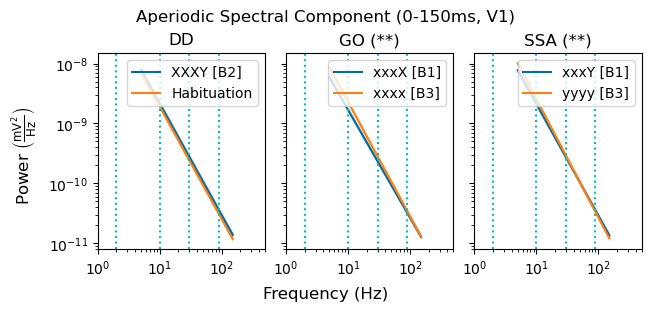

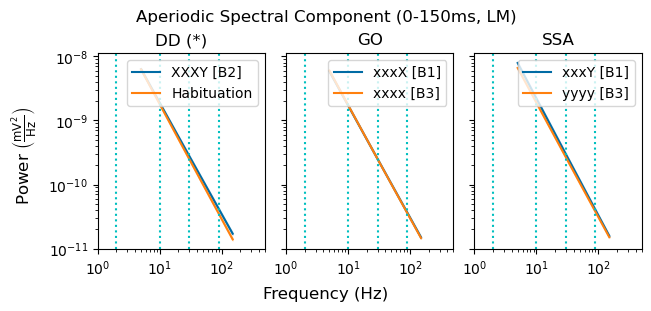

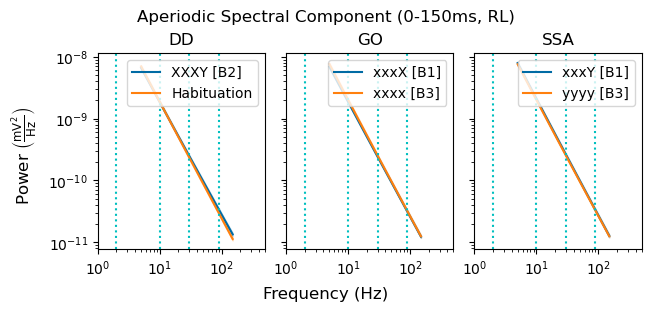

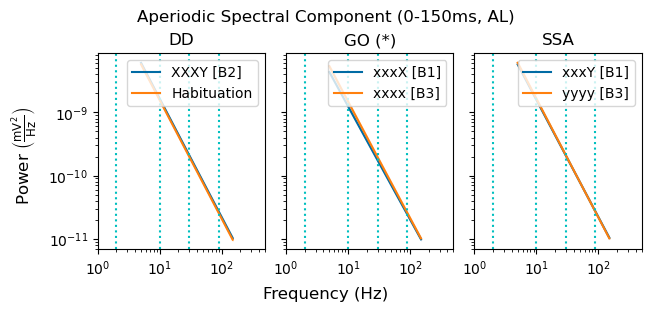

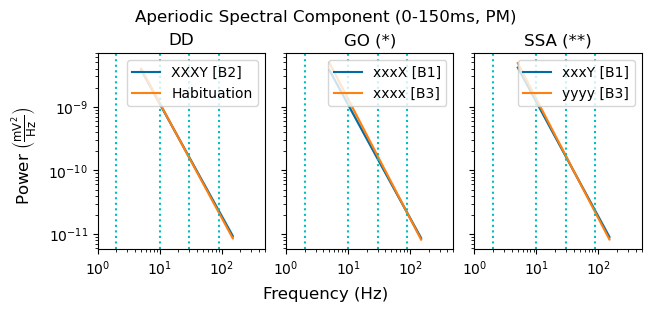

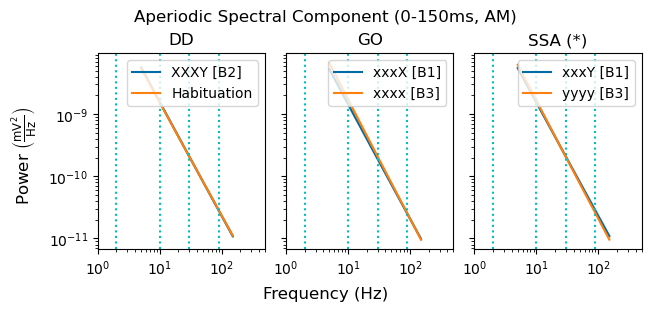

In [36]:
spectrum_trials = collections.defaultdict(lambda: collections.defaultdict(lambda: []))
for cond in CONDITIONS:
    for area in oscillatories[cond]:
        spectrum_trials[area][cond].append(aperiodics[cond][area].squeeze())

for area in anatomical_areas:
    plt.style.use('tableau-colorblind10')
    #               DD, GO, SSA
    # Oddball
    # Control
    # Difference
    fig, axes = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, layout="constrained")
    fig.supxlabel("Frequency (Hz)"); fig.supylabel("Power $\\left(\\frac{\\mathrm{mV}^{2}}{\\mathrm{Hz}}\\right)$")
    fig.suptitle(("Aperiodic Spectral Component (0-150ms, %s)" % AREA_TITLES[area]))
    fig.set_figheight(3)
    for col, (contrast, condl, condr) in enumerate(CONTRASTS):
        axes[col].set_title(CONTRAST_TITLES[contrast] + aperiodic_contrast_significance(contrast, area))
        spectrum_trials[area][condl] = np.concatenate(spectrum_trials[area][condl], axis=-1).squeeze()
        plotting.plot_sem(oscillatories[condl][area].freqs.magnitude, spectrum_trials[area][condl], ax=axes[col], axis=0, sems=2, label=CONDITION_TITLES[condl])
        
        spectrum_trials[area][condr] = np.concatenate(spectrum_trials[area][condr], axis=-1).squeeze()        
        plotting.plot_sem(oscillatories[condr][area].freqs.magnitude, spectrum_trials[area][condr], ax=axes[col], axis=0, sems=2, label=CONDITION_TITLES[condr])

        for boundary in BAND_BOUNDS:
            axes[col].axvline(boundary, color='c', linestyle=':')
        axes[col].set_xlim([1, 500]); axes[col].set_xscale("log");
        axes[col].set_yscale("log"); # axes[col].set_ylim([10e-12, 10e-8])
        axes[col].legend()

        # band_midpoints = [(low + high) / 2 for (low, high) in zip(BAND_BOUNDS, BAND_BOUNDS[1:])]
        # axes[col].set_xticks(band_midpoints, labels=["$\\theta$", "$\\alpha/\\beta$", "$\\gamma$"])

    plt.savefig("%s_fast_aperiodic_spectra.svg" % AREA_TITLES[area])
    plt.savefig("%s_fast_aperiodic_spectra.png" % AREA_TITLES[area])
    plt.show()

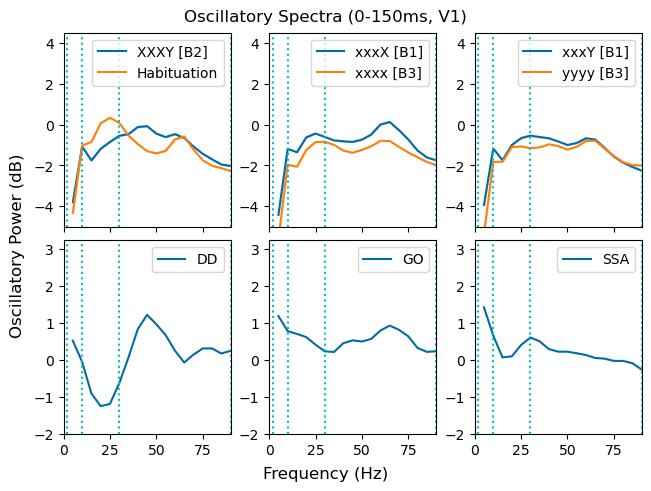

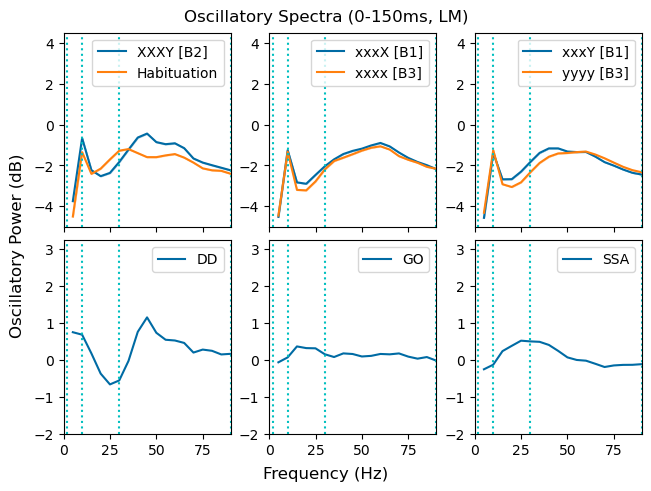

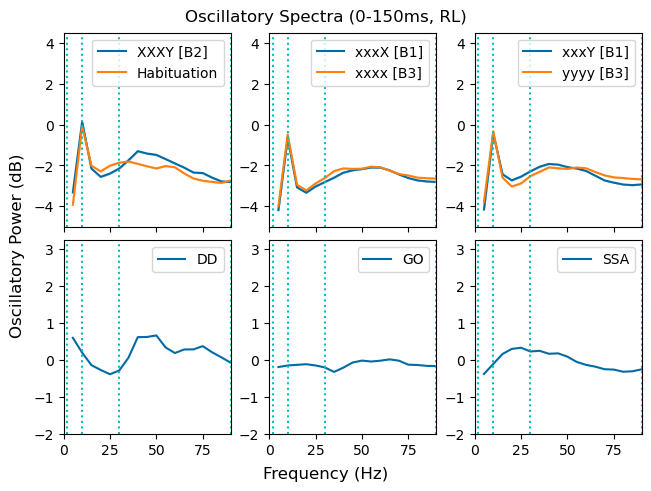

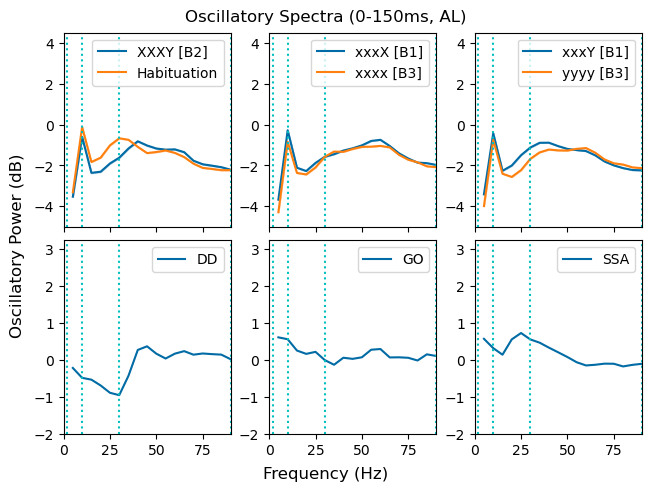

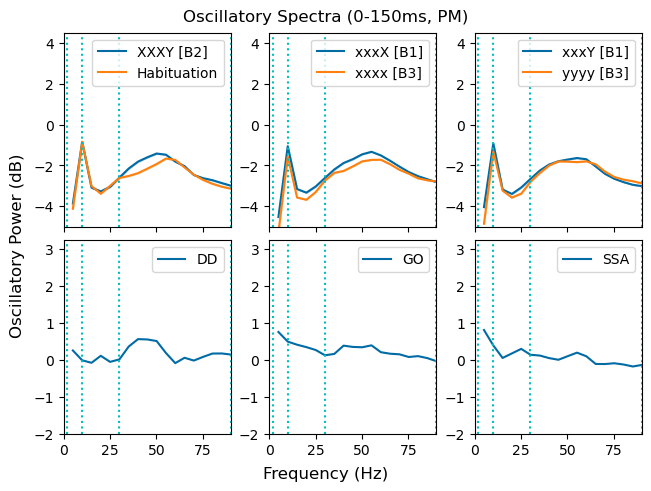

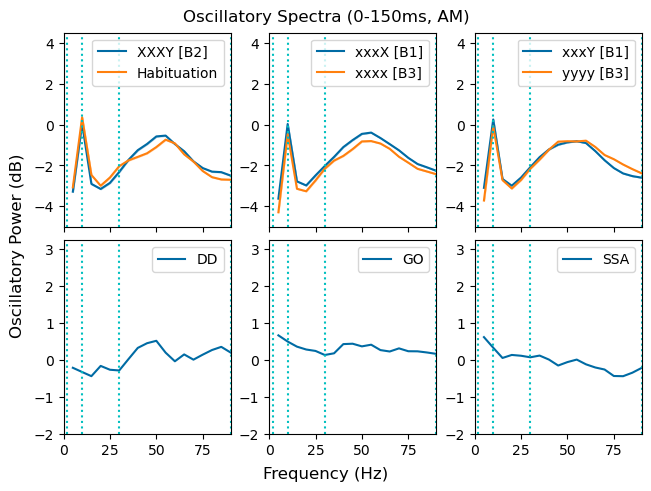

In [32]:
spectrum_trials = collections.defaultdict(lambda: collections.defaultdict(lambda: []))
for cond in CONDITIONS:
    for area in oscillatories[cond]:
        spectrum_trials[area][cond] = oscillatories[cond][area].data.magnitude.mean(axis=0)

for area in anatomical_areas:
    plt.style.use('tableau-colorblind10')
    #               DD, GO, SSA
    # Oddball
    # Control
    # Difference
    fig, axes = plt.subplots(nrows=2, ncols=3, sharex=True, sharey=False, layout="constrained")
    fig.supxlabel("Frequency (Hz)"); fig.supylabel("Oscillatory Power (dB)")
    fig.suptitle(("Oscillatory Spectra (0-150ms, %s)" % AREA_TITLES[area]))
    for col, (contrast, condl, condr) in enumerate(CONTRASTS):
        plotting.plot_sem(oscillatories[condl][area].freqs.magnitude, spectrum_trials[area][condl], ax=axes[0, col], axis=-1, sems=2, label=CONDITION_TITLES[condl])
        plotting.plot_sem(oscillatories[condr][area].freqs.magnitude, spectrum_trials[area][condr], ax=axes[0, col], axis=-1, sems=2, label=CONDITION_TITLES[condr])
        for boundary in BAND_BOUNDS:
            axes[0, col].axvline(boundary, color='c', linestyle=':')
        axes[0, col].set_xlim([0, 90]); axes[0, col].set_ylim([-5, 4.5])
        axes[0, col].legend()

        axes[1, col].plot(oscillatories[condr][area].freqs.magnitude, spectrum_trials[area][condl].mean(axis=-1) - spectrum_trials[area][condr].mean(axis=-1), label=CONTRAST_TITLES[contrast])
        for boundary in BAND_BOUNDS:
            axes[1, col].axvline(boundary, color='c', linestyle=':')
        axes[1, col].set_xlim([0, 90])
        axes[1, col].legend()
        axes[1, col].set_ylim([-2, 3.25])
    plt.show()